# NIH ChestX-ray14 — Multi-Label Chest Pathology Classification
Multi-label classification of 14 chest pathologies from frontal chest X-rays using a
fine-tuned ResNet-18, with Grad-CAM interpretability and documented dataset limitations.
**Dataset:** NIH ChestX-ray14 — 112,120 images, 30,805 patients
**Model:** ResNet-18 pretrained on ImageNet, fine-tuned with per-class weighted loss
**Key difference from binary classification:** each image can have multiple conditions simultaneously

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score

## 2. Configuration

In [2]:
MINI_RUN = False   # True = quick test | False = full run
BASE       = Path("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized")
IMG_DIR    = BASE / "images-224" / "images-224"
CSV_PATH   = BASE / "Data_Entry_2017.csv"
TRAIN_LIST = BASE / "train_val_list_NIH.txt"
TEST_LIST  = BASE / "test_list_NIH.txt"
IMG_SIZE = 224
BATCH_SIZE     = 32
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4
LR             = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")
print(f"\nCSV exists:      {CSV_PATH.exists()}")
print(f"Train list:      {TRAIN_LIST.exists()}")
print(f"Test list:       {TEST_LIST.exists()}")
print(f"PNG files found: {len(list(IMG_DIR.glob('*.png')))}")

Device: cuda
Mode:   FULL

CSV exists:      True
Train list:      True
Test list:       True
PNG files found: 112120


## 3. Load and Explore the Dataset

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(df[["Image Index", "Finding Labels", "Patient ID"]].head(8))

Shape: (112120, 12)

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
        Image Index          Finding Labels  Patient ID
0  00000001_000.png            Cardiomegaly           1
1  00000001_001.png  Cardiomegaly|Emphysema           1
2  00000001_002.png   Cardiomegaly|Effusion           1
3  00000002_000.png              No Finding           2
4  00000003_000.png                  Hernia           3
5  00000003_001.png                  Hernia           3
6  00000003_002.png                  Hernia           3
7  00000003_003.png     Hernia|Infiltration           3


## 4. Parse Multi-Label Column Into 14 Binary Columns

In [4]:
LABELS = [
    "Atelectasis", "Consolidation", "Infiltration", "Pneumothorax",
    "Edema", "Emphysema", "Fibrosis", "Effusion", "Pneumonia",
    "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]
for label in LABELS:
    df[label] = df["Finding Labels"].apply(lambda x: 1 if label in x else 0)
print(f"Total images:             {len(df):,}")
print(f"Images with No Finding:   {(df['Finding Labels'] == 'No Finding').sum():,}")
print(f"Images with >=1 condition: {(df['Finding Labels'] != 'No Finding').sum():,}")

Total images:             112,120
Images with No Finding:   60,412
Images with >=1 condition: 51,708


## 5. Class Distribution

Positive counts and rates per class:
  Infiltration           19,870  (17.7%)
  Effusion               13,307  (11.9%)
  Atelectasis            11,535  (10.3%)
  Nodule                  6,323  (5.6%)
  Mass                    5,746  (5.1%)
  Pneumothorax            5,298  (4.7%)
  Consolidation           4,667  (4.2%)
  Pleural_Thickening      3,385  (3.0%)
  Cardiomegaly            2,772  (2.5%)
  Emphysema               2,516  (2.2%)
  Edema                   2,303  (2.0%)
  Fibrosis                1,686  (1.5%)
  Pneumonia               1,353  (1.2%)
  Hernia                    227  (0.2%)


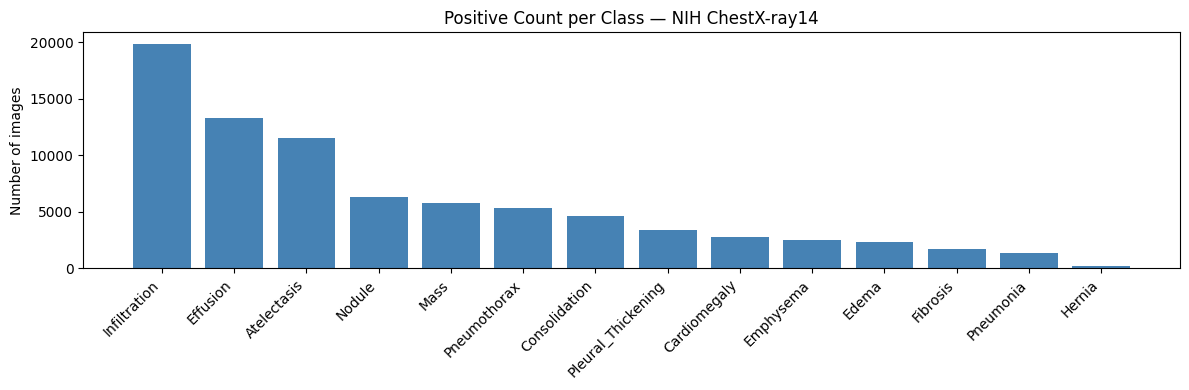

In [5]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)
print("Positive counts and rates per class:")
for label in label_counts.index:
    print(f"  {label:<22} {label_counts[label]:6,}  ({label_pct[label]:.1f}%)")
plt.figure(figsize=(12, 4))
plt.bar(label_counts.index, label_counts.values, color="steelblue")
plt.title("Positive Count per Class — NIH ChestX-ray14")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Label Co-occurrence

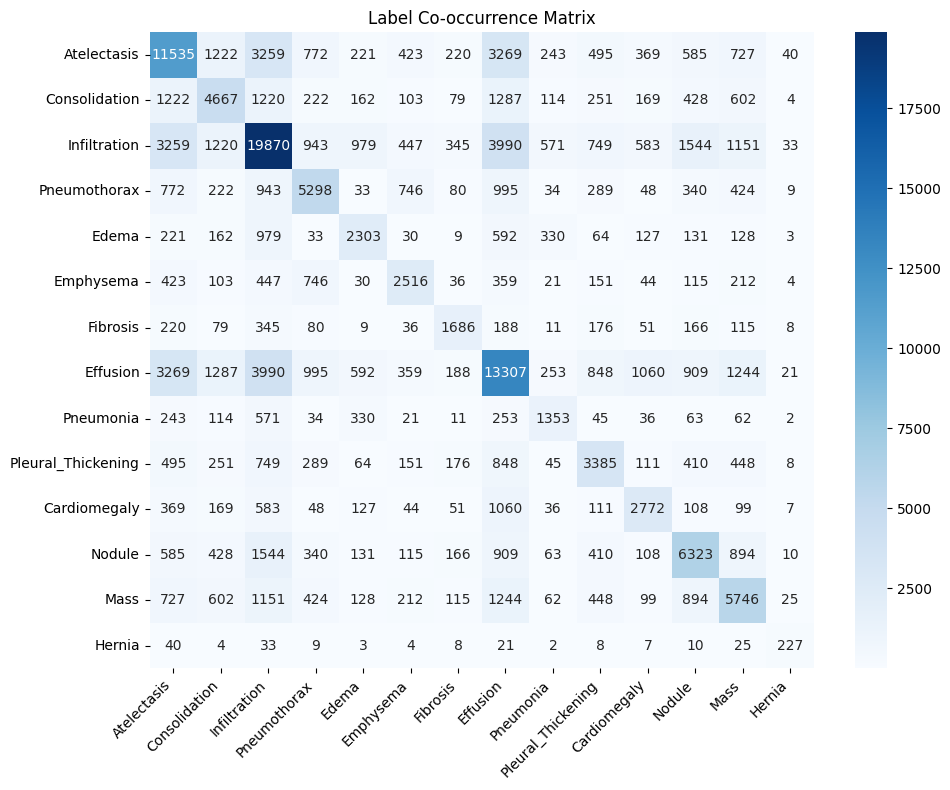

In [6]:
co_matrix = df[LABELS].T.dot(df[LABELS])
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Label Co-occurrence Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Sample Image Per Class

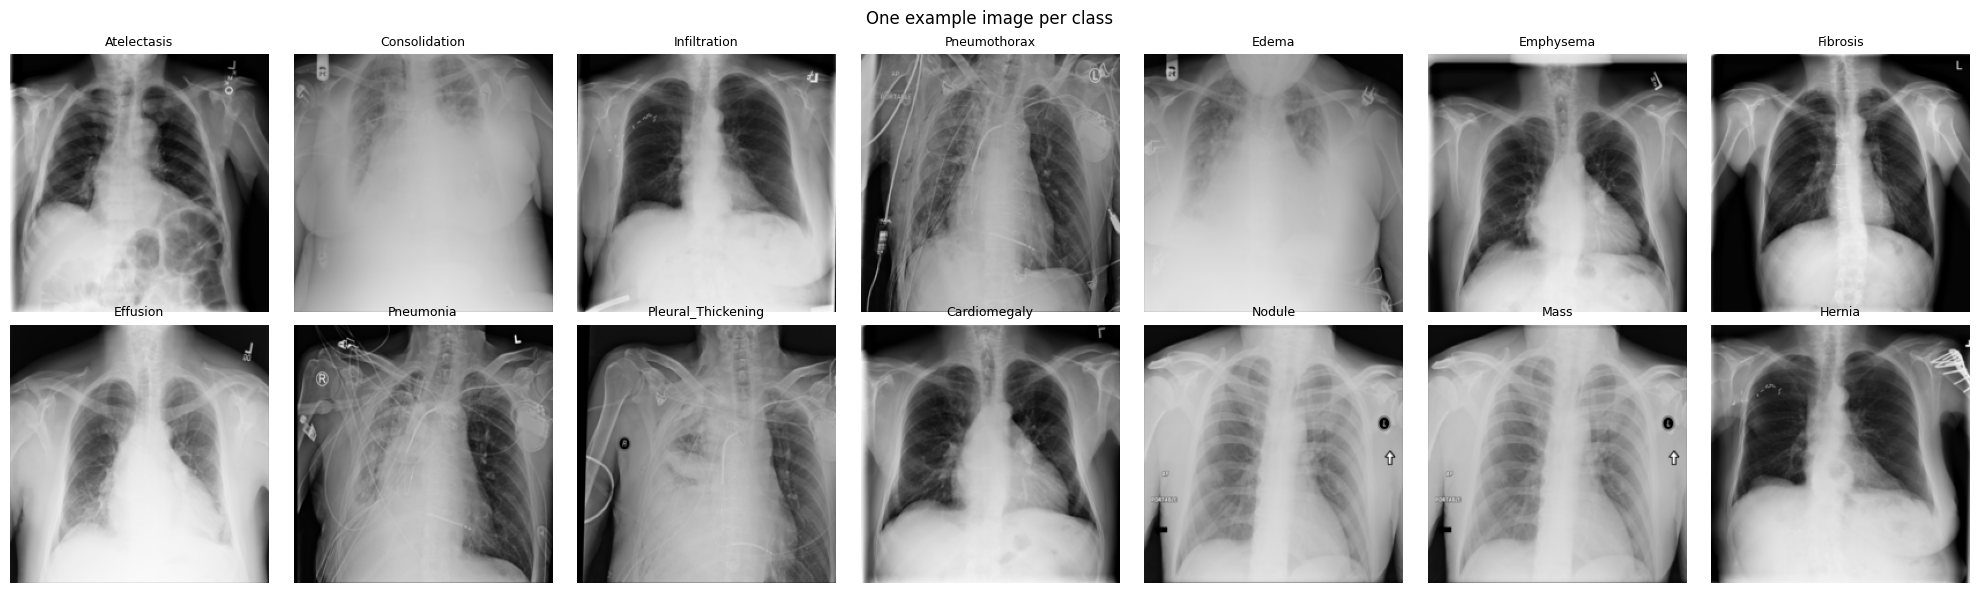

In [7]:
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
axes = axes.flatten()
for i, label in enumerate(LABELS):
    sample_row = df[df[label] == 1].iloc[0]
    img        = Image.open(IMG_DIR / sample_row["Image Index"]).convert("RGB")
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(label, fontsize=9)
    axes[i].axis("off")
plt.suptitle("One example image per class", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Patient-Disjoint Train / Val / Test Split
Official train/test lists provided with the dataset are split by patient. We split
train_val 90/10 by patient ID for validation. Splitting by patient (not image) avoids
leakage from repeat visits by the same patient.

In [8]:
train_val_files = set(open(TRAIN_LIST).read().splitlines())
test_files      = set(open(TEST_LIST).read().splitlines())
df_trainval = df[df["Image Index"].isin(train_val_files)].copy()
df_test     = df[df["Image Index"].isin(test_files)].copy()
trainval_patients = df_trainval["Patient ID"].unique()
np.random.seed(42)
np.random.shuffle(trainval_patients)
n_val        = int(len(trainval_patients) * 0.10)
val_patients = set(trainval_patients[:n_val])
df_train = df_trainval[~df_trainval["Patient ID"].isin(val_patients)]
df_val   = df_trainval[df_trainval["Patient ID"].isin(val_patients)]
print(f"Train: {len(df_train):,} images ({df_train['Patient ID'].nunique():,} patients)")
print(f"Val:   {len(df_val):,} images ({df_val['Patient ID'].nunique():,} patients)")
print(f"Test:  {len(df_test):,} images ({df_test['Patient ID'].nunique():,} patients)")
assert len(set(df_train["Patient ID"]) & set(df_val["Patient ID"]))  == 0
assert len(set(df_train["Patient ID"]) & set(df_test["Patient ID"])) == 0
assert len(set(df_val["Patient ID"])   & set(df_test["Patient ID"])) == 0
print("\nPatient overlap check: PASSED")

Train: 77,994 images (25,208 patients)
Val:   8,530 images (2,800 patients)
Test:  25,596 images (2,797 patients)

Patient overlap check: PASSED


## 9. MINI_RUN Subsetting

In [9]:
if MINI_RUN:
    df_train = df_train.sample(n=min(1000, len(df_train)), random_state=42)
    df_val   = df_val.sample(n=min(200,  len(df_val)),   random_state=42)
    df_test  = df_test.sample(n=min(200,  len(df_test)),  random_state=42)
    print(f"MINI — Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
else:
    print(f"FULL — Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print("\nPositive count per class in train:")
for label in LABELS:
    print(f"  {label:<22} {df_train[label].sum():4d}")

FULL — Train: 77,994 | Val: 8,530 | Test: 25,596

Positive count per class in train:
  Atelectasis            7405
  Consolidation          2584
  Infiltration           12480
  Pneumothorax           2394
  Edema                  1253
  Emphysema              1317
  Fibrosis               1111
  Effusion               7852
  Pneumonia               783
  Pleural_Thickening     1997
  Cardiomegaly           1549
  Nodule                 4247
  Mass                   3646
  Hernia                  122


## 10. Dataset Class

In [10]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.img_dir / row["Image Index"]).convert("RGB")
        label = torch.tensor(row[LABELS].values.astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, label

## 11. Transforms and DataLoaders
RandomHorizontalFlip only — no vertical flip (the heart must stay at the top) and no
rotation beyond what's clinically plausible for an upright X-ray.

In [11]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
train_ds = ChestXrayDataset(df_train, IMG_DIR, transform=train_transform)
val_ds   = ChestXrayDataset(df_val,   IMG_DIR, transform=val_test_transform)
test_ds  = ChestXrayDataset(df_test,  IMG_DIR, transform=val_test_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
imgs_b, labels_b = next(iter(train_loader))
print(f"Batch image shape: {imgs_b.shape}")
print(f"Batch label shape: {labels_b.shape}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32, 14])


## 12. Per-Class pos_weight

In [12]:
pos_counts = df_train[LABELS].sum().values.astype(np.float32)
neg_counts = len(df_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.clip(pos_counts, 1, None),
                          dtype=torch.float32).to(DEVICE)
print("Per-class pos_weight:")
for i, label in enumerate(LABELS):
    print(f"  {label:<22} pos={int(pos_counts[i]):5d}  weight={pos_weight[i].item():.1f}")

Per-class pos_weight:
  Atelectasis            pos= 7405  weight=9.5
  Consolidation          pos= 2584  weight=29.2
  Infiltration           pos=12480  weight=5.2
  Pneumothorax           pos= 2394  weight=31.6
  Edema                  pos= 1253  weight=61.2
  Emphysema              pos= 1317  weight=58.2
  Fibrosis               pos= 1111  weight=69.2
  Effusion               pos= 7852  weight=8.9
  Pneumonia              pos=  783  weight=98.6
  Pleural_Thickening     pos= 1997  weight=38.1
  Cardiomegaly           pos= 1549  weight=49.4
  Nodule                 pos= 4247  weight=17.4
  Mass                   pos= 3646  weight=20.4
  Hernia                 pos=  122  weight=638.3


## 13. Model

In [13]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 14)
model = model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", patience=2, factor=0.5)
print(f"Output layer: {model.fc}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]

Output layer: Linear(in_features=512, out_features=14, bias=True)
Parameters:   11,183,694


## 14. Training
**Fix applied:** the AUC loop previously used a bare `except: pass`, which silently
swallowed *any* error, not just the "no positives in this batch" case it was meant to
handle. It now catches `ValueError` specifically and prints which class/why it was
skipped, so a real bug can't hide behind this loop again.

In [14]:
best_auc, patience_count = 0.0, 0
history = {"train_loss": [], "val_auc": []}
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(imgs)
    train_loss = running_loss / len(train_ds)
    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            val_probs.extend(probs)
            val_targets.extend(labels.numpy())
    val_probs   = np.array(val_probs)
    val_targets = np.array(val_targets)
    aucs = []
    for i in range(14):
        if val_targets[:, i].sum() > 0:
            try:
                aucs.append(roc_auc_score(val_targets[:, i], val_probs[:, i]))
            except ValueError as e:
                print(f"  Skipping {LABELS[i]} (val): {e}")
    val_auc = np.mean(aucs)
    scheduler.step(val_auc)
    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)
    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    if val_auc > best_auc:
        best_auc, patience_count = val_auc, 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break
print(f"\nBest Val Mean AUC: {best_auc:.4f}")

Epoch 01/20 | Train Loss: 1.1196 | Val AUC: 0.7393 | LR: 1.00e-04
Epoch 02/20 | Train Loss: 1.0424 | Val AUC: 0.7992 | LR: 1.00e-04
Epoch 03/20 | Train Loss: 0.9810 | Val AUC: 0.8027 | LR: 1.00e-04
Epoch 04/20 | Train Loss: 0.9420 | Val AUC: 0.8041 | LR: 1.00e-04
Epoch 05/20 | Train Loss: 0.9134 | Val AUC: 0.8091 | LR: 1.00e-04
Epoch 06/20 | Train Loss: 0.8501 | Val AUC: 0.8166 | LR: 1.00e-04
Epoch 07/20 | Train Loss: 0.8151 | Val AUC: 0.8113 | LR: 1.00e-04
Epoch 08/20 | Train Loss: 0.7731 | Val AUC: 0.8094 | LR: 1.00e-04
Epoch 09/20 | Train Loss: 0.7154 | Val AUC: 0.8101 | LR: 5.00e-05
Epoch 10/20 | Train Loss: 0.6120 | Val AUC: 0.8064 | LR: 5.00e-05

Early stopping at epoch 10.

Best Val Mean AUC: 0.8166


## 15. Training Curves

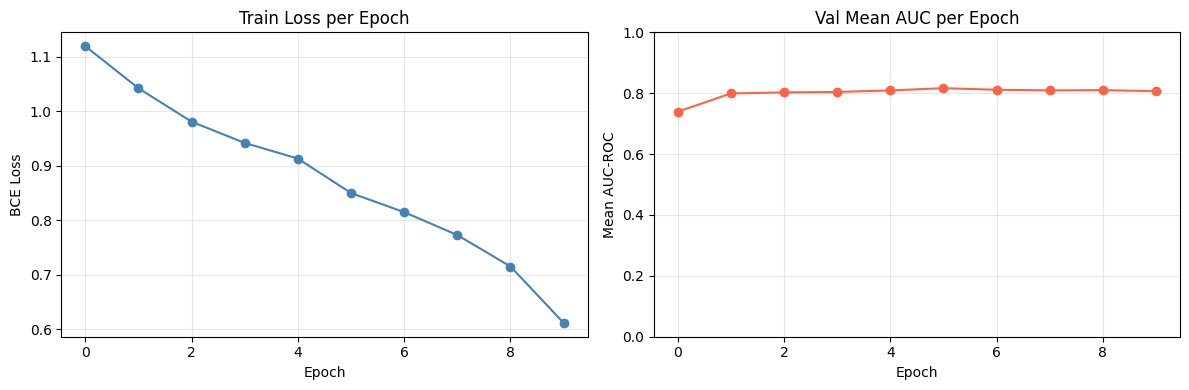

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], marker="o", color="steelblue")
ax1.set_title("Train Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.grid(True, alpha=0.3)
ax2.plot(history["val_auc"], marker="o", color="tomato")
ax2.set_title("Val Mean AUC per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean AUC-ROC")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Test Evaluation — AUC Per Class
**Fix applied:** same bare-except issue as Cell 14, fixed the same way.

In [16]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()
test_probs, test_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())
test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)
print(f"{'Class':<22} {'AUC':>6}")
print("-" * 30)
class_aucs = []
for i, label in enumerate(LABELS):
    if test_targets[:, i].sum() > 0:
        try:
            auc = roc_auc_score(test_targets[:, i], test_probs[:, i])
            class_aucs.append(auc)
            print(f"{label:<22} {auc:.4f}")
        except ValueError as e:
            print(f"{label:<22}   N/A ({e})")
    else:
        print(f"{label:<22}   N/A (no positives in test)")
print("-" * 30)
print(f"{'Mean AUC':<22} {np.mean(class_aucs):.4f}")

Class                     AUC
------------------------------
Atelectasis            0.7453
Consolidation          0.7161
Infiltration           0.6919
Pneumothorax           0.8398
Edema                  0.8388
Emphysema              0.8768
Fibrosis               0.8010
Effusion               0.8091
Pneumonia              0.6884
Pleural_Thickening     0.7564
Cardiomegaly           0.8726
Nodule                 0.7088
Mass                   0.7831
Hernia                 0.9213
------------------------------
Mean AUC               0.7892


## 17. Grad-CAM (qualitative, n=1 per class)
Generates heatmaps for the single highest-confidence true positive per class. This is a
qualitative check only — Cells 18-22 below add a quantitative version against NIH's
bounding-box annotations.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.5 MB/s eta 0:00:00


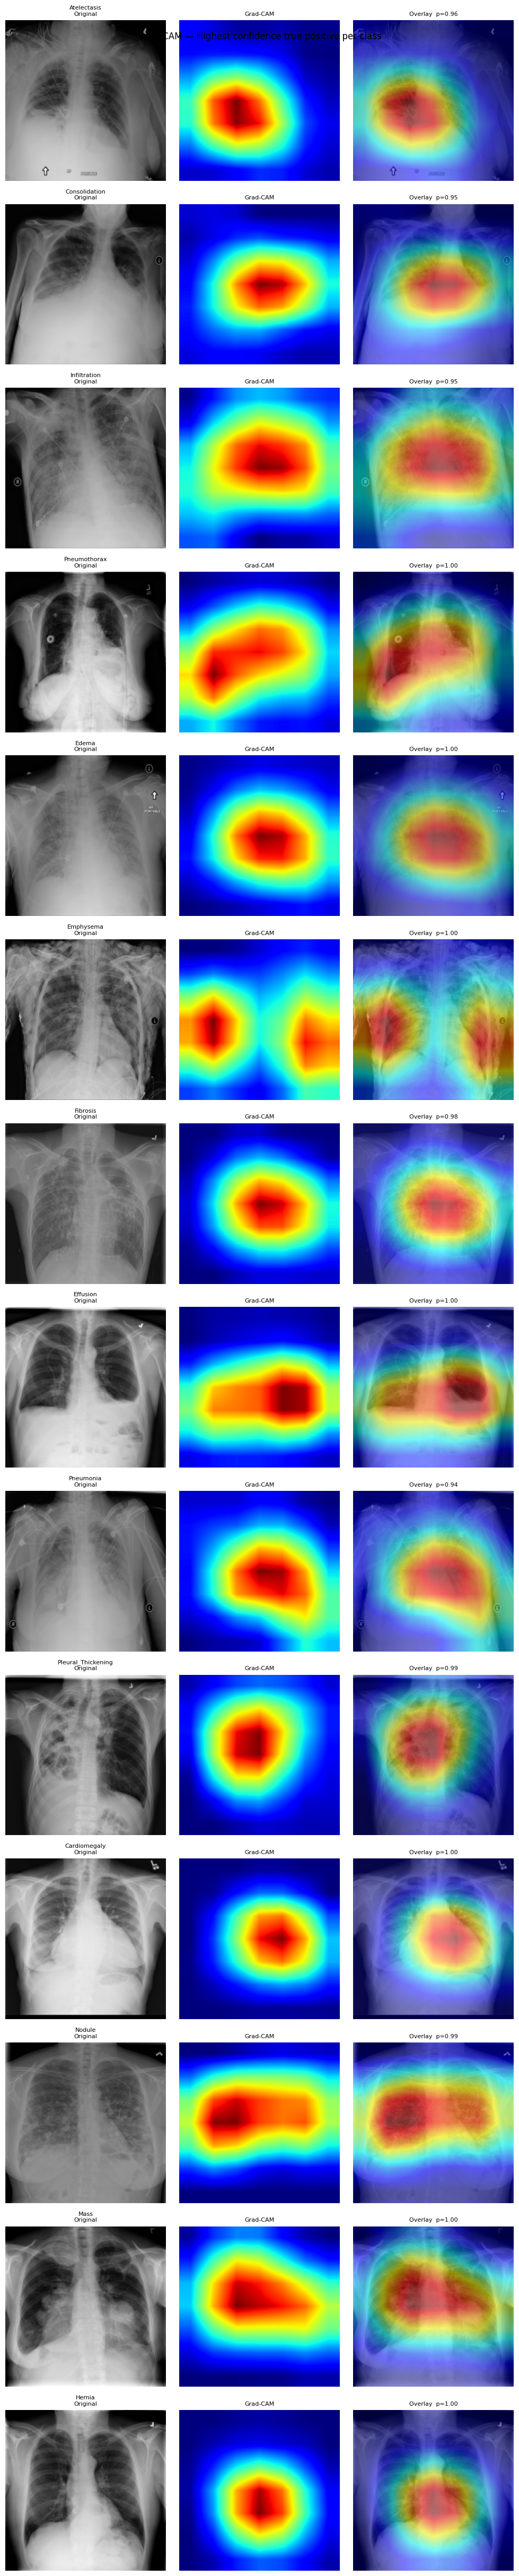

In [17]:
subprocess.run(["pip", "install", "grad-cam", "-q"])
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 14)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model = model.to(DEVICE)
model.eval()
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
n_classes_with_pos = sum(1 for i in range(14) if test_targets[:, i].sum() > 0)
fig, axes = plt.subplots(n_classes_with_pos, 3, figsize=(10, n_classes_with_pos * 3.5))
row = 0
for class_idx, label in enumerate(LABELS):
    pos_mask = test_targets[:, class_idx] == 1
    if pos_mask.sum() == 0:
        continue
    class_probs = test_probs[pos_mask, class_idx]
    best_local  = np.argmax(class_probs)
    best_global = np.where(pos_mask)[0][best_local]
    prob        = class_probs[best_local]
    row_data   = test_ds.df.iloc[best_global]
    img_pil    = Image.open(IMG_DIR / row_data["Image Index"]).convert("RGB")
    img_np     = np.array(img_pil).astype(np.float32) / 255.0
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(class_idx)]
    heatmap = cam(input_tensor=img_tensor, targets=targets)[0]
    overlay = show_cam_on_image(img_np, heatmap, use_rgb=True)
    axes[row, 0].imshow(img_pil, cmap="gray")
    axes[row, 0].set_title(f"{label}\nOriginal", fontsize=8)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM", fontsize=8)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Overlay  p={prob:.2f}", fontsize=8)
    axes[row, 2].axis("off")
    row += 1
plt.suptitle("Grad-CAM — Highest confidence true positive per class", fontsize=12)
plt.tight_layout()
plt.show()

---# Additional Analyses
The four analyses below were flagged as missing from the original submission:
rare-class AUCs reported without any uncertainty, a bias hypothesis (AP vs PA) asserted
in prose but never tested, no subgroup (age/gender) performance check, and Grad-CAM
conclusions drawn from one image per class. Each cell below turns one of those into an
actual measured number.

## 18. Bootstrap 95% CIs on Test AUC per Class

In [18]:
def bootstrap_auc_ci(y_true, y_score, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_t, y_s = y_true[idx], y_score[idx]
        if y_t.sum() == 0 or y_t.sum() == n:
            continue
        boot_aucs.append(roc_auc_score(y_t, y_s))
    boot_aucs = np.array(boot_aucs)
    lo = np.percentile(boot_aucs, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_aucs, (1 + ci) / 2 * 100)
    return lo, hi
auc_ci_rows = []
for i, label in enumerate(LABELS):
    y_true, y_score = test_targets[:, i], test_probs[:, i]
    n_pos = int(y_true.sum())
    if n_pos == 0:
        continue
    point_auc = roc_auc_score(y_true, y_score)
    lo, hi = bootstrap_auc_ci(y_true, y_score)
    auc_ci_rows.append({
        "Class": label, "AUC": round(point_auc, 4),
        "CI_low": round(lo, 4), "CI_high": round(hi, 4),
        "CI_width": round(hi - lo, 4), "Test_positives": n_pos,
    })
auc_ci_df = pd.DataFrame(auc_ci_rows).sort_values("AUC", ascending=False)
print(auc_ci_df.to_string(index=False))
auc_ci_df.to_csv("/kaggle/working/test_auc_bootstrap_ci.csv", index=False)

             Class    AUC  CI_low  CI_high  CI_width  Test_positives
            Hernia 0.9213  0.8830   0.9551    0.0721              86
         Emphysema 0.8768  0.8670   0.8873    0.0203            1093
      Cardiomegaly 0.8726  0.8621   0.8826    0.0204            1065
      Pneumothorax 0.8398  0.8329   0.8470    0.0141            2661
             Edema 0.8388  0.8275   0.8492    0.0217             925
          Effusion 0.8091  0.8024   0.8160    0.0136            4648
          Fibrosis 0.8010  0.7797   0.8213    0.0416             435
              Mass 0.7831  0.7723   0.7940    0.0217            1712
Pleural_Thickening 0.7564  0.7430   0.7703    0.0273            1143
       Atelectasis 0.7453  0.7362   0.7537    0.0175            3255
     Consolidation 0.7161  0.7059   0.7265    0.0207            1815
            Nodule 0.7088  0.6957   0.7213    0.0256            1615
      Infiltration 0.6919  0.6842   0.6996    0.0154            6088
         Pneumonia 0.6884  0.6647 

## 19. Subgroup AUC by Patient Age and Patient Gender

In [19]:
test_meta = test_ds.df.copy().reset_index(drop=True)
test_meta["Patient Age"] = pd.to_numeric(test_meta["Patient Age"], errors="coerce")
n_bad_age = int((test_meta["Patient Age"] > 100).sum())
test_meta.loc[test_meta["Patient Age"] > 100, "Patient Age"] = np.nan
print(f"Excluded {n_bad_age} rows with implausible age (>100) from age analysis")
age_bins = [0, 20, 40, 60, 80, 120]
age_labels = ["0-19", "20-39", "40-59", "60-79", "80+"]
test_meta["Age Band"] = pd.cut(test_meta["Patient Age"], bins=age_bins,
                                labels=age_labels, right=False)
def stratified_auc(mask, class_idx):
    y_t, y_s = test_targets[mask, class_idx], test_probs[mask, class_idx]
    n_pos = int(y_t.sum())
    if n_pos == 0 or n_pos == len(y_t):
        return np.nan, n_pos
    return roc_auc_score(y_t, y_s), n_pos
gender_rows = []
for i, label in enumerate(LABELS):
    for gender in ["M", "F"]:
        mask = (test_meta["Patient Gender"] == gender).values
        auc, n_pos = stratified_auc(mask, i)
        gender_rows.append({"Class": label, "Gender": gender,
                             "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
gender_df = pd.DataFrame(gender_rows)
gender_pivot = gender_df.pivot(index="Class", columns="Gender", values="AUC")
gender_pivot["Gap (M-F)"] = gender_pivot["M"] - gender_pivot["F"]
print("\n--- AUC by Gender ---")
print(gender_pivot.sort_values("Gap (M-F)", key=abs, ascending=False).round(4))
gender_df.to_csv("/kaggle/working/subgroup_auc_gender.csv", index=False)
age_rows = []
for i, label in enumerate(LABELS):
    for band in age_labels:
        mask = (test_meta["Age Band"] == band).values
        auc, n_pos = stratified_auc(mask, i)
        age_rows.append({"Class": label, "Age Band": band,
                          "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
age_df = pd.DataFrame(age_rows)
age_pivot = age_df.pivot(index="Class", columns="Age Band", values="AUC")
print("\n--- AUC by Age Band ---")
print(age_pivot.round(4))
age_df.to_csv("/kaggle/working/subgroup_auc_age.csv", index=False)

Excluded 0 rows with implausible age (>100) from age analysis

--- AUC by Gender ---
Gender                   F       M  Gap (M-F)
Class                                        
Hernia              0.9668  0.8709    -0.0960
Fibrosis            0.7599  0.8321     0.0721
Nodule              0.7322  0.6926    -0.0396
Pleural_Thickening  0.7703  0.7462    -0.0241
Effusion            0.7948  0.8187     0.0239
Mass                0.7720  0.7913     0.0193
Pneumonia           0.6802  0.6946     0.0144
Atelectasis         0.7377  0.7507     0.0129
Emphysema           0.8727  0.8792     0.0065
Edema               0.8416  0.8366    -0.0050
Pneumothorax        0.8413  0.8382    -0.0031
Consolidation       0.7176  0.7151    -0.0025
Cardiomegaly        0.8706  0.8729     0.0023
Infiltration        0.6912  0.6923     0.0011

--- AUC by Age Band ---
Age Band            0-19  20-39  40-59  60-79  80+
Class                                             
Atelectasis          NaN    NaN    NaN    NaN  NaN
C

## 20. View-Position (AP/PA) Stratified AUC
Directly tests the README's acquisition-bias hypothesis: that Pneumothorax, Effusion,
and Atelectasis AUC is inflated by film type (portable AP vs standard PA) acting as a
confounder rather than the model isolating the pathology itself.

In [20]:
view_rows = []
for i, label in enumerate(LABELS):
    for view in ["AP", "PA"]:
        mask = (test_meta["View Position"] == view).values
        auc, n_pos = stratified_auc(mask, i)
        view_rows.append({"Class": label, "View": view,
                           "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
view_df = pd.DataFrame(view_rows)
view_pivot = view_df.pivot(index="Class", columns="View", values="AUC")
view_pivot["Gap (AP-PA)"] = view_pivot["AP"] - view_pivot["PA"]
print("\n--- AUC by View Position (all classes) ---")
print(view_pivot.sort_values("Gap (AP-PA)", ascending=False).round(4))
hypothesis_classes = ["Pneumothorax", "Effusion", "Atelectasis"]
print("\n--- Hypothesis check: acquisition-type confounding ---")
print(view_pivot.loc[hypothesis_classes].round(4))
print(
    "\nA large positive gap here (AP >> PA) is consistent with the "
    "    'acquisition-type-as-proxy' hypothesis in README Limitation 3. A small "
    "    'or negative gap would argue against it. Either way, this is now a "
    "    'measured result, not an assumption.")
view_df.to_csv("/kaggle/working/view_position_auc.csv", index=False)


--- AUC by View Position (all classes) ---
View                    AP      PA  Gap (AP-PA)
Class                                          
Infiltration        0.6631  0.6151       0.0480
Fibrosis            0.7996  0.7569       0.0427
Emphysema           0.8931  0.8606       0.0325
Pleural_Thickening  0.7501  0.7344       0.0157
Pneumonia           0.6630  0.6496       0.0133
Pneumothorax        0.8321  0.8395      -0.0074
Atelectasis         0.7406  0.7514      -0.0108
Nodule              0.6914  0.7168      -0.0254
Hernia              0.8891  0.9169      -0.0278
Edema               0.7673  0.8111      -0.0438
Mass                0.7559  0.8047      -0.0487
Effusion            0.7801  0.8429      -0.0628
Consolidation       0.6603  0.7247      -0.0644
Cardiomegaly        0.8220  0.9280      -0.1060

--- Hypothesis check: acquisition-type confounding ---
View              AP      PA  Gap (AP-PA)
Class                                    
Pneumothorax  0.8321  0.8395      -0.0074
Effusi

## 21. Quantitative Grad-CAM Localization (IoU / AP@0.25 / AP@0.50)
Replaces the n=1-per-class qualitative check in Cell 17 with a measured result against
NIH's official bounding-box annotations. Restricted to bbox images that fall inside the
TEST split, to avoid reporting localization quality on images the model was trained on.

In [21]:
from scipy import ndimage
assert "cam" in globals() and "model" in globals(), (
    "Run Cell 17 first — this cell reuses the GradCAM object and loaded model.")
BBOX_CANDIDATES = [
    BASE / "BBox_List_2017_Official_NIH.csv",
    BASE / "BBox_List_2017.csv",
    Path("/kaggle/input/data/BBox_List_2017.csv"),
]
bbox_path = next((p for p in BBOX_CANDIDATES if p.exists()), None)
if bbox_path is None:
    raise FileNotFoundError(
        "No bounding-box CSV found among the expected filenames/paths. "
        "Check the dataset's exact filename and add it to BBOX_CANDIDATES."
    )
bbox_df = pd.read_csv(bbox_path)
bbox_df.columns = ["Image_Index", "Finding_Label", "x", "y", "w", "h"] + \
                   list(bbox_df.columns[6:])
# The bbox file spells this class "Infiltrate"; Data_Entry_2017.csv (and LABELS) use
# "Infiltration".
bbox_df["Finding_Label" ] = bbox_df["Finding_Label"].replace(
    {"Infiltrate": "Infiltration"})
bbox_test = bbox_df[bbox_df["Image_Index"].isin(set(df_test["Image Index"]))].copy()
print(f"Bounding boxes total: {len(bbox_df)} | overlapping with test split: {len(bbox_test)}")
if len(bbox_test) < 50:
    print(
        "WARNING: small overlap with the test split — per-class localization "
        "numbers below will have wide, effectively-unreported uncertainty. "
        "Treat as directional, especially for classes with n<15."
    )
ORIG_SIZE = 1024  # NIH ChestX-ray14 native resolution; bbox coords are in this frame
scale = IMG_SIZE / ORIG_SIZE
bbox_test["x_s"] = bbox_test["x"] * scale
bbox_test["y_s"] = bbox_test["y"] * scale
bbox_test["w_s"] = bbox_test["w"] * scale
bbox_test["h_s"] = bbox_test["h"] * scale
def heatmap_to_bbox(heatmap, threshold=0.5):
    binary = (heatmap >= threshold).astype(np.uint8)
    if binary.sum() == 0:
        return None
    labeled, n_components = ndimage.label(binary)
    sizes = ndimage.sum(binary, labeled, range(1, n_components + 1))
    largest_label = np.argmax(sizes) + 1
    ys, xs = np.where(labeled == largest_label)
    return float(xs.min()), float(ys.min()), float(xs.max() - xs.min() + 1), float(ys.max() - ys.min() + 1)
def iou(box_a, box_b):
    ax1, ay1, aw, ah = box_a
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx1, by1, bw, bh = box_b
    bx2, by2 = bx1 + bw, by1 + bh
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0
LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}
model.eval()
localization_rows = []
for _, row in bbox_test.iterrows():
    label = row["Finding_Label"]
    if label not in LABEL_TO_IDX:
        continue
    img_path = IMG_DIR / row["Image_Index"]
    if not img_path.exists():
        continue
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    heatmap = cam(input_tensor=img_tensor,
                  targets=[ClassifierOutputTarget(LABEL_TO_IDX[label])])[0]
    gt_box = (row["x_s"], row["y_s"], row["w_s"], row["h_s"])
    pred_box = heatmap_to_bbox(heatmap, threshold=0.5)
    score = iou(pred_box, gt_box) if pred_box is not None else 0.0
    localization_rows.append({"Image_Index": row["Image_Index"],
                               "Class": label, "IoU": score})
loc_df = pd.DataFrame(localization_rows)
loc_summary = loc_df.groupby("Class")["IoU"].agg(n="count", mean_IoU="mean").reset_index()
loc_summary["AP@0.25"] = loc_df.groupby("Class")["IoU"].apply(lambda s: (s >= 0.25).mean()).values
loc_summary["AP@0.50"] = loc_df.groupby("Class")["IoU"].apply(lambda s: (s >= 0.50).mean()).values
loc_summary = loc_summary.sort_values("mean_IoU", ascending=False).round(4)
print("\n--- Quantitative Grad-CAM localization vs Cell 17's n=1 impression ---")
print(loc_summary.to_string(index=False))
print(
    "\nNote: threshold=0.5 and 'largest connected component' are methodology "
    "choices, not the only valid ones — report them as such if this goes in the README.")
loc_df.to_csv("/kaggle/working/gradcam_localization_raw.csv", index=False)
loc_summary.to_csv("/kaggle/working/gradcam_localization_summary.csv", index=False)

Bounding boxes total: 984 | overlapping with test split: 984

--- Quantitative Grad-CAM localization vs Cell 17's n=1 impression ---
       Class   n  mean_IoU  AP@0.25  AP@0.50
Cardiomegaly 146    0.5422   0.9452   0.6986
Infiltration 123    0.2039   0.3171   0.0894
   Pneumonia 120    0.1818   0.3333   0.0583
    Effusion 153    0.1575   0.2484   0.0261
        Mass  85    0.1245   0.1647   0.0471
Pneumothorax  98    0.0870   0.1122   0.0204
 Atelectasis 180    0.0745   0.0500   0.0056
      Nodule  79    0.0154   0.0000   0.0000

Note: threshold=0.5 and 'largest connected component' are methodology choices, not the only valid ones — report them as such if this goes in the README.


## 22. Markdown Summary Tables (paste-ready for the README)

In [22]:
try:
    import tabulate  # noqa: F401
except ImportError:
    subprocess.run(["pip", "install", "tabulate", "-q"])
print("\n### Test AUC with 95% bootstrap CI\n")
print(auc_ci_df.to_markdown(index=False, floatfmt=".4f"))
print("\n### AUC by Gender\n")
print(gender_pivot.round(4).to_markdown())
print("\n### AUC by Age Band\n")
print(age_pivot.round(4).to_markdown())
print("\n### AUC by View Position — acquisition-bias hypothesis check\n")
print(view_pivot.loc[hypothesis_classes].round(4).to_markdown())
print("\n### Quantitative Grad-CAM localization (replaces n=1 Cell 17 impression)\n")
print(loc_summary.to_markdown(index=False))
print(
    "\nAll CSVs are in /kaggle/working/. Send the printed markdown tables "
    "(or the CSVs) back to fold real numbers into the README's placeholder sections.")


### Test AUC with 95% bootstrap CI

| Class              |    AUC |   CI_low |   CI_high |   CI_width |   Test_positives |
|:-------------------|-------:|---------:|----------:|-----------:|-----------------:|
| Hernia             | 0.9213 |   0.8830 |    0.9551 |     0.0721 |               86 |
| Emphysema          | 0.8768 |   0.8670 |    0.8873 |     0.0203 |             1093 |
| Cardiomegaly       | 0.8726 |   0.8621 |    0.8826 |     0.0204 |             1065 |
| Pneumothorax       | 0.8398 |   0.8329 |    0.8470 |     0.0141 |             2661 |
| Edema              | 0.8388 |   0.8275 |    0.8492 |     0.0217 |              925 |
| Effusion           | 0.8091 |   0.8024 |    0.8160 |     0.0136 |             4648 |
| Fibrosis           | 0.8010 |   0.7797 |    0.8213 |     0.0416 |              435 |
| Mass               | 0.7831 |   0.7723 |    0.7940 |     0.0217 |             1712 |
| Pleural_Thickening | 0.7564 |   0.7430 |    0.7703 |     0.0273 |             1143 |
| Atel